In [91]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as Transforms
import torch.optim as optims
from torch.utils.data import DataLoader
import math


In [92]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")

In [93]:
my_transform = Transforms.Compose([
    Transforms.ToTensor(),
    Transforms.Normalize((0,),(1,)),
    #Transforms.Lambda(lambda x: x.view(-1))  #use when using ann wala :p
])

In [94]:
train_dataset = torchvision.datasets.MNIST(root='./data',train = True, transform=my_transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train= True, transform=my_transform, download=True)

In [95]:
train_dataloader = DataLoader(dataset= train_dataset, batch_size=64, shuffle= True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=True)

In [96]:
def reparametrization(mu,log_var):

    sigma = torch.exp(0.5*log_var)

    epsilon = torch.randn_like(sigma)

    z = mu + sigma*epsilon

    return z

In [97]:
class VAE_ANN(nn.Module):
    def __init__(self):
        super(VAE_ANN,self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(in_features=28*28,out_features=400),
            nn.ReLU()
        )

        self.mu = nn.Linear(in_features=400,out_features=20)

        self.var = nn.Sequential(
            nn.Linear(in_features=400,out_features=20),
            #nn.Softplus()  #i mean, log_var use krre toh i dont assume we need this??? obv kyuki, e ki powers me hoga and if it becomes positive then it can be problamatic
        )

        self.decoder = nn.Sequential(
            nn.Linear(in_features=20,out_features=400),
            nn.ReLU(),
            nn.Linear(in_features=400,out_features=28*28),
            nn.Sigmoid() #nigga chose relu and wondered why got gradient ascend
        )

    def forward(self,x):
        x = self.encoder(x)

        Mu = self.mu(x)

        Log_Var = self.var(x) 

        Z = reparametrization(Mu,Log_Var)

        output = self.decoder(Z)

        return output, Mu, Log_Var   

In [98]:
class VAE_CNN(nn.Module):
    def __init__(self):
        super(VAE_CNN,self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16,kernel_size=3,stride=1,padding=0),
            nn.ReLU()
        )

        #self.mu = nn.Conv2d(in_channels=16,out_channels=64,kernel_size=4,stride=2,padding=0)
        #self.log_var = nn.Conv2d(in_channels=16,out_channels=64,kernel_size=4,stride=2,padding=0)

        self.mu = nn.Sequential(
            nn.Linear(in_features=10816,out_features=2704),
            nn.ReLU(),
            nn.Linear(in_features=2704,out_features=676),
            nn.ReLU(),
            nn.Linear(in_features=676,out_features=20)
        )
        
        self.log_var = nn.Sequential(
            nn.Linear(in_features=10816,out_features=2704),
            nn.ReLU(),
            nn.Linear(in_features=2704,out_features=676),
            nn.ReLU(),
            nn.Linear(in_features=676,out_features=20),
        )

        self.expand = nn.Linear(in_features=20,out_features=9216)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64,out_channels=16,kernel_size=4,stride=2,padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16,out_channels=1,kernel_size=3,stride=1,padding=0),
            nn.Sigmoid()
        )

    def forward(self,x):

        x1 = self.encoder(x)

        x1_flat = torch.flatten(x1,start_dim=1)

        Mu = self.mu(x1_flat)

        Log_Var = self.log_var(x1_flat)

        Z = reparametrization(Mu,Log_Var)

        z1 = self.expand(Z)

        z1_reshaped = z1.view(-1,64,12,12)

        output = self.decoder(z1_reshaped)

        return output,Mu,Log_Var

In [99]:
class VAE1(nn.Module):#avoid this(first architecture btw)
    def __init__(self):
        super(VAE1,self).__init__()


        self.encoder = nn.Sequential(
            nn.Linear(in_features=28*28,out_features=400),
            nn.ReLU(),

            mu = nn.Linear(in_features=400,out_features=20),

            var = nn.Linear(in_features=400, out_features=20)
        )

        self.decoder = nn.Sequential(
            nn.Linear(in_features=20,out_features=400),
            nn.ReLU(),

            nn.Linear(in_features=400,out_features=28*28),
            nn.Sigmoid()
        )

    def forward(self,x):

        mu1 , var1 = self.encoder(x)

        z = reparametrization(mu1,var1)

        output = self.decoder(z)

        return output

In [100]:
def vae_loss(output,x,mu,log_var):

    #loss1 = nn.BCELoss(output,x,reduction=sum)
    #taking sum for reduction here coz when we take log likelihood we take the sum of every log, and thus we need a sum here not an average
    #reduction means, when we are comparing each pixel of an image, we get a tensor of images, so when using reduction we can either take average of the vlaue we get.. or by taking sum, we get a summation of all the values we took and by none means we take teh entire tensor
    
    loss1 = nn.functional.binary_cross_entropy(output,x,reduction='sum')
    
    #print(loss1).. it was indeed a bad idea lmfao

    loss2 = 0.5 * torch.sum( torch.exp(log_var) + mu**2 - 1 - log_var )
    
    #print(loss2)

    #loss2 = 0.5 * torch.sum( mu**2 + var - 1 - torch.log(var))   #when considering the output of encoder is var instead of log of var

    
    return loss1 + loss2

In [101]:
model = VAE_CNN()
model.to(device)

#criterion = vae_loss()

optimizer = optims.Adam(model.parameters(),lr=0.0001) 

In [102]:
num_epochs = 25

In [103]:
for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for images,labels in train_dataloader:#notice how we are iterating for labels too while we dont need them here.. its because we need to unpack them or else we wont be able to fully iterate
        images = images.to(device)#why not do just images.to(device).. because moving tensors and the paramteres of the model are two different things completely. when you do model.to(device), it physically takes the weights to the device of model. now when we do like images.to(device).. what happens is we  take a copy of that tensor and hand it to the gpu. the images still sit physically with us in cpu. we need to get it back from the gpu too.

        output,mu,var = model(images)

        loss = vae_loss(output,images,mu,var)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item() #if only = hoga tb sirf last wala jo element hoga uska loss uthayega..

    print(f"Epoch {epoch+1}/{num_epochs}  Loss: {total_loss/len(train_dataloader.dataset):.4f}")    

Epoch 1/25  Loss: 199.8821
Epoch 2/25  Loss: 130.3345
Epoch 3/25  Loss: 123.1079
Epoch 4/25  Loss: 119.5058
Epoch 5/25  Loss: 116.6461
Epoch 6/25  Loss: 114.2143
Epoch 7/25  Loss: 112.2911
Epoch 8/25  Loss: 110.7779
Epoch 9/25  Loss: 109.5620
Epoch 10/25  Loss: 108.6326
Epoch 11/25  Loss: 107.8232
Epoch 12/25  Loss: 107.1498
Epoch 13/25  Loss: 106.5620
Epoch 14/25  Loss: 106.0719
Epoch 15/25  Loss: 105.6259
Epoch 16/25  Loss: 105.1866
Epoch 17/25  Loss: 104.8043
Epoch 18/25  Loss: 104.4335
Epoch 19/25  Loss: 104.1174
Epoch 20/25  Loss: 103.8520
Epoch 21/25  Loss: 103.5454
Epoch 22/25  Loss: 103.3047
Epoch 23/25  Loss: 103.0368
Epoch 24/25  Loss: 102.8783
Epoch 25/25  Loss: 102.5806


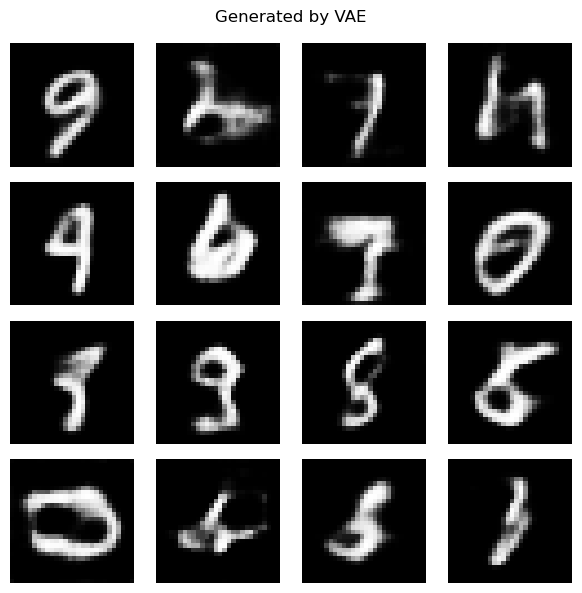

In [110]:
import matplotlib.pyplot as plt

# 1. Pull model to CPU for testing
model.cpu()
model.eval()

with torch.no_grad():
    # 2. Start at the TRUE bottleneck (16 images, 20 dimensions each)
    noise = torch.randn(16, 20)
    
    # 3. Cross the bridge! Expand the 20 numbers into 9216
    z_expanded = model.expand(noise)
    
    # 4. Reshape it into the 64x12x12 grid the CNN expects
    z_reshaped = z_expanded.view(-1, 64, 12, 12)
    
    # 5. NOW pass it to the decoder
    fake_images = model.decoder(z_reshaped)
    
    # Drop the channel dimension for plotting
    fake_images = fake_images.squeeze().numpy()

# Plot the 16 images in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i], cmap='gray')
    ax.axis('off')


fig.suptitle("Generated by VAE")
plt.tight_layout()
plt.show()

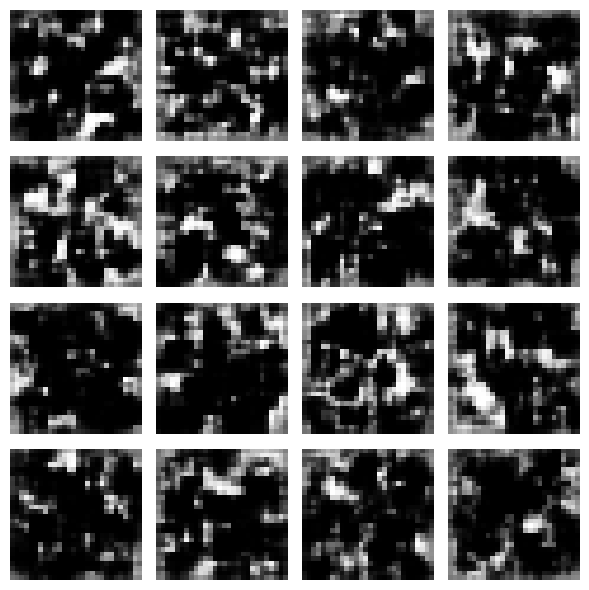

In [108]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()    